In [1]:
# Python import
import os
import copy
import random
import itertools
import numpy as np
import pandas as pd
import lightgbm as lgb
import warnings
import joblib
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
import lightgbm as lgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import uniform, randint
from ngboost import NGBClassifier
from catboost import CatBoostClassifier
from ngboost.distns import k_categorical
# from sklearn.metrics import roc_auc_score
# from skopt import BayesSearchCV
# from skopt.space import Real, Integer, Categorical

/lulabdata3/huangkeyun/miniconda/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
from sklearn.impute import SimpleImputer
def find_test_indices(x_kmer, x_test, tolerance):
    """
    逐行比较 x_test 和 x_kmer，找到 x_test 在 x_kmer 中的对应索引。
    
    参数：
    - x_kmer: 原始特征矩阵（numpy array）
    - x_test: 测试集特征矩阵（numpy array）
    - tolerance: 浮动误差容忍值，默认为 1e-6
    
    返回：
    - x_test_indices: 对应的原始行索引列表
    """
    indices = []
    for row in x_test:
        # 逐行比较，容忍浮动误差
        matches = np.where(np.all(np.abs(x_kmer - row) < tolerance, axis=1))[0]
        # if len(matches) != 1:
        #     raise ValueError(f"找到了多个或没有匹配行: {matches}")
        indices.append(matches[0])
    return indices


In [3]:
def balance_dataset_by_tag(df, tag_column='tag', random_state=42):
    """
    df : pd.DataFrame
        需要处理的原始数据集。
    tag_column : str, 默认 'tag'
        用于分割数据的列名，默认是 'tag'。
    random_state : int, 默认 42
    返回:
    pd.DataFrame
        平衡后的数据集，tag列为0和1的行数一致。
    """
    # 分割数据集为 tag=0 和 tag=1 的两部分
    df_tag_0 = df[df[tag_column] == 0]
    df_tag_1 = df[df[tag_column] == 1]

    # 判断哪个数据集较大，然后对较大的数据集进行下采样
    if len(df_tag_0) > len(df_tag_1):
        df_tag_0_downsampled = resample(df_tag_0, 
                                        replace=False,  # 不允许重复采样
                                        n_samples=len(df_tag_1),  # 调整为与tag=1一致
                                        random_state=random_state)  # 设置随机种子
        df_balanced = pd.concat([df_tag_0_downsampled, df_tag_1])
    else:
        df_tag_1_downsampled = resample(df_tag_1, 
                                        replace=False,  # 不允许重复采样
                                        n_samples=len(df_tag_0),  # 调整为与tag=0一致
                                        random_state=random_state)  # 设置随机种子
        df_balanced = pd.concat([df_tag_0, df_tag_1_downsampled])

    # 打乱数据集的顺序
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return df_balanced


In [4]:
# Count the frequency of k-mer in each RNA sequence
# k-mer was normalized by total k-mer count of each RNA sequence
def _count_kmer(Dataset, k):  # k = 3, 4, 5
    
    # copy dataset
    dataset = copy.deepcopy(Dataset)
    # alphabet of nucleotide
    nucleotide = ['A', 'C', 'G', 'T']
    
    # generate k-mers
    #  k == 5:
    five = list(itertools.product(nucleotide, repeat=5))
    pentamer = [''.join(n) for n in five]
    
    #  k == 4:
    four = list(itertools.product(nucleotide, repeat=4))
    tetramer = [''.join(n) for n in four]

    # k == 3:
    three = list(itertools.product(nucleotide, repeat=3))
    threemer = [''.join(n) for n in three]
    
    # input features can be combinations of different k values
    if k == 34:
        table_kmer = dict.fromkeys(threemer, 0)
        table_kmer.update(dict.fromkeys(tetramer, 0))
    elif k == 45:
        table_kmer = dict.fromkeys(tetramer, 0)
        table_kmer.update(dict.fromkeys(pentamer, 0))
    elif k == 345:
        table_kmer = dict.fromkeys(threemer, 0)
        table_kmer.update(dict.fromkeys(tetramer, 0))
        table_kmer.update(dict.fromkeys(pentamer, 0))

    # count k-mer for each sequence
    for mer in table_kmer.keys():
        table_kmer[mer] = dataset["Sequence"].apply(lambda x: x.count(mer))
    
    # for k-mer raw count without normalization, index: nuc:1 or cyto:0
    rawcount_kmer_df = pd.DataFrame(table_kmer)
    df1_rawcount = pd.concat([rawcount_kmer_df, dataset["RNA_Symbol"]], axis=1)
    df1_rawcount.index = dataset["tag"]

    # for k-mer frequency with normalization, index: nuc:1 or cyto:0
    freq_kmer_df = rawcount_kmer_df.apply(lambda x: x / x.sum(), axis=1)
    df1 = pd.concat([freq_kmer_df, dataset["RNA_Symbol"]], axis=1)
    df1.index = dataset["tag"]

    return df1, df1_rawcount


In [5]:
#Evaluate performance of model
def evaluate_performance(y_test, y_pred, y_prob):
    # AUROC
    auroc = metrics.roc_auc_score(y_test,y_prob)
    auroc_curve = metrics.roc_curve(y_test, y_prob)
    # AUPRC
    auprc=metrics.average_precision_score(y_test, y_prob) 
    auprc_curve=metrics.precision_recall_curve(y_test, y_prob)
    #Accuracy
    accuracy=metrics.accuracy_score(y_test,y_pred) 
    #MCC
    mcc=metrics.matthews_corrcoef(y_test,y_pred)
    
    recall=metrics.recall_score(y_test, y_pred)
    precision=metrics.precision_score(y_test, y_pred)
    f1=metrics.f1_score(y_test, y_pred)
    class_report=metrics.classification_report(y_test, y_pred,target_names = ["control","case"])

    model_perf = {"auroc":auroc,"auroc_curve":auroc_curve,
                  "auprc":auprc,"auprc_curve":auprc_curve,
                  "accuracy":accuracy, "mcc": mcc,
                  "recall":recall,"precision":precision,"f1":f1,
                  "class_report":class_report}
        
    return model_perf

In [6]:
# Output result of evaluation
def eval_output(model_perf,path):
    with open(os.path.join(path,"Evaluate_Result_TestSet.txt"),'w') as f:
        f.write("AUROC=%s\tAUPRC=%s\tAccuracy=%s\tMCC=%s\tRecall=%s\tPrecision=%s\tf1_score=%s\n" %
               (model_perf["auroc"],model_perf["auprc"],model_perf["accuracy"],model_perf["mcc"],model_perf["recall"],model_perf["precision"],model_perf["f1"]))
        f.write("\n######NOTE#######\n")
        f.write("#According to help_documentation of sklearn.metrics.classification_report:in binary classification, recall of the positive class is also known as sensitivity; recall of the negative class is specificity#\n\n")
        f.write(model_perf["class_report"])

In [7]:
# Plot AUROC of model
def plot_AUROC(model_perf,path):
    #get AUROC,FPR,TPR and threshold
    roc_auc = model_perf["auroc"]
    fpr,tpr,threshold = model_perf["auroc_curve"]
    #return AUROC info
    temp_df = pd.DataFrame({"FPR":fpr,"TPR":tpr})
    temp_df.to_csv(os.path.join(path,"AUROC_info.txt"),header = True,index = False, sep = '\t')
    #plot
    plt.figure()
    lw = 2
    plt.figure(figsize=(10,10))
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='AUROC (area = %0.2f)' % roc_auc) 
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC of Models")
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(path,"AUROC_TestSet.pdf"),format = "pdf")

In [8]:
def RF_classification(x_train, y_train, x_test, y_test, output_dir, SEED=42, n_ter = 100):
    # Construct Random Forest model
    print("\n*** Random Forest  ***")

    # Random Forest params
    rf_param_dict = {
        "n_estimators": [10, 50, 100, 200, 500, 1000],
        "max_depth": [None, 10, 20, 50, 100],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ['auto', 'sqrt', 'log2'],
        "random_state": [SEED]
    }

    # Initiate model
    rf_model = RandomForestClassifier()
    # Adjust hyper-parameters with 5-fold cross-validation
    rf_rscv = RandomizedSearchCV(rf_model, rf_param_dict, n_iter=n_ter, cv=5, verbose=0,
                                scoring="roc_auc", random_state=SEED, n_jobs=30)
    rf_rscv.fit(x_train, y_train)

    # Evaluate best Random Forest model
    # Output path
    path = os.path.join(output_dir, "RandomForest")
    if not (os.path.exists(path)):
        os.mkdir(path)

    # Model performance(AUROC) on cross-validation dataset
    rf_cv_perf = np.array([rf_rscv.cv_results_["split%s_test_score" % str(i)] for i in range(5)])[:, rf_rscv.best_index_]

    # Get best model with score [max(mean(auc(5 cross validation)))]
    rf_best_model = rf_rscv.best_estimator_
    # Get predict_class(y_pred) and predict_probability_for_case(y_prob) of TestSet
    y_pred = rf_best_model.predict(x_test)
    y_prob = rf_best_model.predict_proba(x_test)[:, 1]

    # Get model performance
    model_perf = evaluate_performance(y_test, y_pred, y_prob)
    # Output result of evaluation
    eval_output(model_perf, path)
    # You can make bar plot consisted of accuracy, sensitivity, specificity, auroc, f1 score, MCC, precision, recall, auprc according to the "Evaluate_Result_TestSet.txt"
    # Plot AUROC
    plot_AUROC(model_perf, path)

    # Save model
    joblib.dump(rf_best_model, os.path.join(path, "best_RandomForest_model.pkl"))
    return model_perf


In [9]:
# Random seed
SEED = 198
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings(action='ignore')

# Output dir
output_dir = "./circRNA_ML_Model_rigor_Output"
if not (os.path.exists(output_dir)):
    os.mkdir(output_dir)

In [13]:
# 读取 validation set
val_df = pd.read_csv('/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_intra5fold_Output/val_dataset.csv')

# 读取训练集原始数据
dataset = pd.read_csv(
    '/lulabdata3/huangkeyun/zhangys/RNA_locator/archived/circExor_archived_2025_5/sample_preprocessing/circRNA/output_with_sequences.csv',
    sep='\t',
    index_col=False
)
dataset_filtered = dataset[["RNA_Symbol", "Subcellular_Localization", "Sequence"]]

# 2. 添加标签
dataset_filtered['tag'] = dataset_filtered['Subcellular_Localization'].map({
    "Cytosol": 0,
    "Nucleus": 0,
    "Extracellular vesicle": 1
})

# 3. 划分训练集：根据 RNA_Symbol 删除与 val set 重合的条目
train_df = dataset_filtered[~dataset_filtered['RNA_Symbol'].isin(val_df['RNA_Symbol'])]
train_df = balance_dataset_by_tag(train_df, tag_column='tag', random_state=42)
# 4. 分别提取训练集和验证集的 k-mer 特征
df_kmer_train, df_kmer_train_raw = _count_kmer(train_df, 345)
df_kmer_val, df_kmer_val_raw = _count_kmer(val_df, 345)

# 保存特征
df_kmer_train.to_csv(os.path.join(output_dir, "train_kmer345_freq.tsv"), sep='\t')
df_kmer_train_raw.to_csv(os.path.join(output_dir, "train_kmer345_rawcount.tsv"), sep='\t')
df_kmer_val.to_csv(os.path.join(output_dir, "val_kmer345_freq.tsv"), sep='\t')
df_kmer_val_raw.to_csv(os.path.join(output_dir, "val_kmer345_rawcount.tsv"), sep='\t')

# 5. 获取训练和验证数据的特征矩阵 + 标签
x_train = df_kmer_train.drop(columns=["RNA_Symbol"]).values
x_val = df_kmer_val.drop(columns=["RNA_Symbol"]).values
# y_train = df_kmer_train.index
# y_test = df_kmer_test.index
y_train = train_df["tag"].values
y_val = val_df["tag"].values

# 6. 缺失值处理
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_val = imputer.transform(x_val)


*** Random Forest  ***


<Figure size 640x480 with 0 Axes>

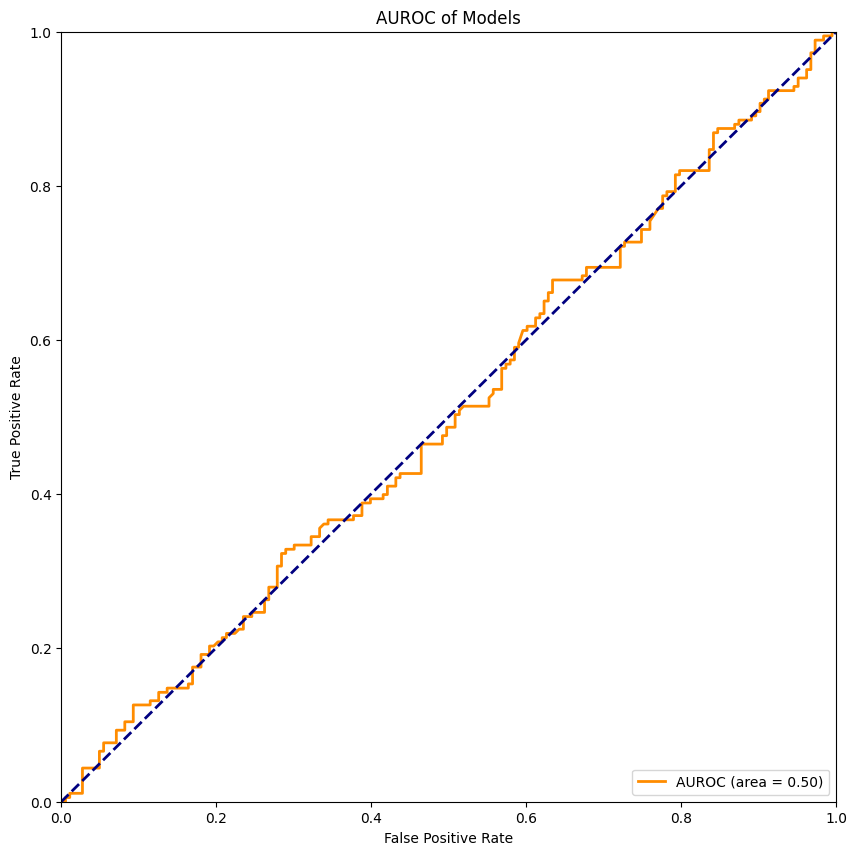

In [14]:
RF_perf = RF_classification(x_test=x_val, x_train=x_train,y_test=y_val,y_train=y_train, output_dir=output_dir)